# Titanic: Machine Learning from Disaster

Bài thực hành xây dựng mạng MLP đơn giản bằng PyTorch để dự đoán hành khách sống sót trên Titanic.

Quy trình:

1. Import thư viện
2. Cấu hình kịch bản
3. Load Data
4. Data Analysis
5. Data Preprocessing
6. Define Model
7. Fit Model
8. Model Evaluation
9. Tuning
10. Prediction
11. Submission

## 1. Import thư viện

In [1]:
import os, glob, json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import wandb

## 2. Cấu hình kịch bản và quản lý thí nghiệm

Toàn bộ kịch bản được điều khiển bằng một từ điển `params`.

Mỗi thí nghiệm tạo một thư mục riêng:

```text
experiments/
└── titanic_mlp_v1/
    ├── best_model.pt
    ├── params.json
    ├── tuning_results.csv
    └── images/
        ├── figure_001.png
        ├── figure_002.png
        └── ...
```

Trong đó:

- `best_model.pt`: mô hình tốt nhất.
- `params.json`: bản sao đầy đủ của `params` dùng cho thí nghiệm.
- `tuning_results.csv`: kết quả các cấu hình tuning.
- `images/`: lưu hình matplotlib.
- `submission.csv` lưu tại params["experiment"]["submission_dir"]

### 2.1. Khởi tạo đường dẫn lưu kết quả


In [4]:
# ============================================================
# TOÀN BỘ THAM SỐ CỦA NOTEBOOK
# Chỉ cần chỉnh sửa từ điển params này để thay đổi kịch bản
# ============================================================

params = {

    # --------------------------------------------------------
    # 1. Dữ liệu
    # --------------------------------------------------------
    "data": {
        "input_dir": "/kaggle/input/competitions/titanic",
        "train_file": "train.csv",
        "test_file": "test.csv",
        "validation_size": 0.30,
        "random_state": 1
    },

    # --------------------------------------------------------
    # 2. Thí nghiệm và nơi lưu kết quả
    # --------------------------------------------------------
    "experiment": {
        "expr_dir": "experiments",
        "expr_name": "titanic_mlp_v1",

        # File lưu trong thư mục thí nghiệm
        "best_model_file": "best_model.pt",
        "params_file": "params.json",

        # Lưu hình phát sinh từ matplotlib
        "save_figures": True,
        "images_dir": "images",
        "figure_dpi": 150,

        # Submission có thể đặt riêng với thư mục thí nghiệm
        # "."               -> thư mục hiện tại
        # "/kaggle/working" -> vị trí thuận tiện trên Kaggle
        "submission_file": "submission.csv",
        "submission_dir": "/kaggle/working"
    },

    # --------------------------------------------------------
    # 3. W&B
    # --------------------------------------------------------
    "wandb": {
        "mode": "disabled",   # đổi thành "online" để dùng W&B
        "project": "titanic-pytorch"
    },

    # --------------------------------------------------------
    # 4. Huấn luyện mặc định
    # --------------------------------------------------------
    "train": {
        "hidden1": 32,
        "hidden2": 16,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 100
    },

    # --------------------------------------------------------
    # 5. Các cấu hình tuning
    # --------------------------------------------------------
    "tuning": [
        {
            "name": "small",
            "hidden1": 16,
            "hidden2": 8,
            "learning_rate": 0.001,
            "batch_size": 32,
            "epochs": 100
        },
        {
            "name": "medium",
            "hidden1": 32,
            "hidden2": 16,
            "learning_rate": 0.001,
            "batch_size": 32,
            "epochs": 100
        },
        {
            "name": "large",
            "hidden1": 64,
            "hidden2": 32,
            "learning_rate": 0.001,
            "batch_size": 32,
            "epochs": 100
        }
    ]
}

In [5]:
# ============================================================
# KHỞI TẠO THƯ MỤC VÀ CÁC ARTIFACT CỦA THÍ NGHIỆM
# ============================================================

# Thư mục gốc của thí nghiệm
expr_path = os.path.join(
    params["experiment"]["expr_dir"],
    params["experiment"]["expr_name"]
)
os.makedirs(expr_path, exist_ok=True)

# Các file nằm trực tiếp trong thư mục thí nghiệm
best_model_path = os.path.join(
    expr_path,
    params["experiment"]["best_model_file"]
)

params_path = os.path.join(
    expr_path,
    params["experiment"]["params_file"]
)

# Thư mục chứa ảnh
images_path = os.path.join(
    expr_path,
    params["experiment"]["images_dir"]
)

if params["experiment"]["save_figures"]:
    os.makedirs(images_path, exist_ok=True)

# Submission có thể đặt ở vị trí khác với thư mục thí nghiệm
submission_dir = params["experiment"]["submission_dir"]
os.makedirs(submission_dir, exist_ok=True)

submission_path = os.path.join(
    submission_dir,
    params["experiment"]["submission_file"]
)


# ------------------------------------------------------------
# 1. Dump params xuống JSON
# ------------------------------------------------------------
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(params, f, ensure_ascii=False, indent=4)


# ------------------------------------------------------------
# 2. Tự động lưu mọi matplotlib figure tại thời điểm plt.show()
# ------------------------------------------------------------
_original_plt_show = plt.show
_figure_counter = 0

def show_and_save(*args, **kwargs):
    global _figure_counter

    if params["experiment"]["save_figures"] and plt.get_fignums():
        _figure_counter += 1

        figure_name = f"figure_{_figure_counter:03d}.png"
        figure_path = os.path.join(images_path, figure_name)

        fig = plt.gcf()
        fig.savefig(
            figure_path,
            dpi=params["experiment"]["figure_dpi"],
            bbox_inches="tight"
        )

        print(f"[FIGURE] Đã lưu: {figure_path}")

    return _original_plt_show(*args, **kwargs)

plt.show = show_and_save


# ------------------------------------------------------------
# Thông tin khởi tạo
# ------------------------------------------------------------
print("=" * 70)
print("BẮT ĐẦU THÍ NGHIỆM")
print("Thời gian        :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("PyTorch          :", torch.__version__)
print("expr_path        :", expr_path)
print("params_path      :", params_path)
print("best_model_path  :", best_model_path)
print("images_path      :", images_path)
print("submission_path  :", submission_path)
print("=" * 70)

print("\nTHAM SỐ HUẤN LUYỆN:")
print(params["train"])

print("\nCÁC CẤU HÌNH TUNING:")
for cfg in params["tuning"]:
    print(cfg)

BẮT ĐẦU THÍ NGHIỆM
Thời gian        : 2026-09-17 15:49:57
PyTorch          : 2.14.0+cpu
expr_path        : experiments\titanic_mlp_v1
params_path      : experiments\titanic_mlp_v1\params.json
best_model_path  : experiments\titanic_mlp_v1\best_model.pt
images_path      : experiments\titanic_mlp_v1\images
submission_path  : /kaggle/working\submission.csv

THAM SỐ HUẤN LUYỆN:
{'hidden1': 32, 'hidden2': 16, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}

CÁC CẤU HÌNH TUNING:
{'name': 'small', 'hidden1': 16, 'hidden2': 8, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}
{'name': 'medium', 'hidden1': 32, 'hidden2': 16, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}
{'name': 'large', 'hidden1': 64, 'hidden2': 32, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}


## 3. Load Data

In [ ]:
import os
import pandas as pd

input_dir = r"C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Titanic\data"

train = pd.read_csv(os.path.join(input_dir, params["data"]["train_file"]))
test = pd.read_csv(os.path.join(input_dir, params["data"]["test_file"]))

print("Số hành khách trong train:", len(train))
print("Số hành khách trong test :", len(test))

train.head()

Số hành khách trong train: 891
Số hành khách trong test : 418


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Data Analysis

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
print("Giá trị thiếu trong train:")
print(train.isnull().sum())

Giá trị thiếu trong train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


[FIGURE] Đã lưu: experiments\titanic_mlp_v1\images\figure_001.png


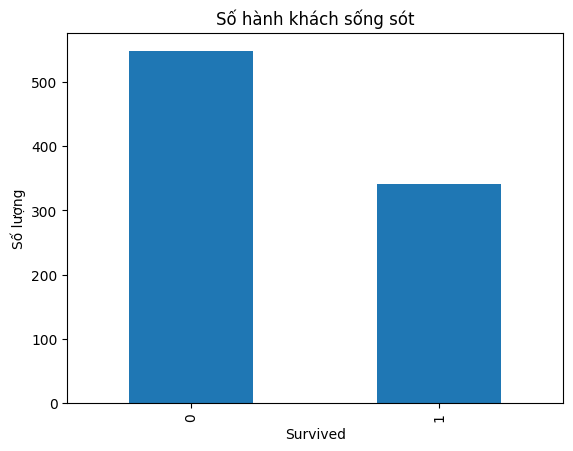

In [10]:
# Số hành khách sống sót / không sống sót
train["Survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Số hành khách sống sót")
plt.xlabel("Survived")
plt.ylabel("Số lượng")
plt.show()

[FIGURE] Đã lưu: experiments\titanic_mlp_v1\images\figure_002.png


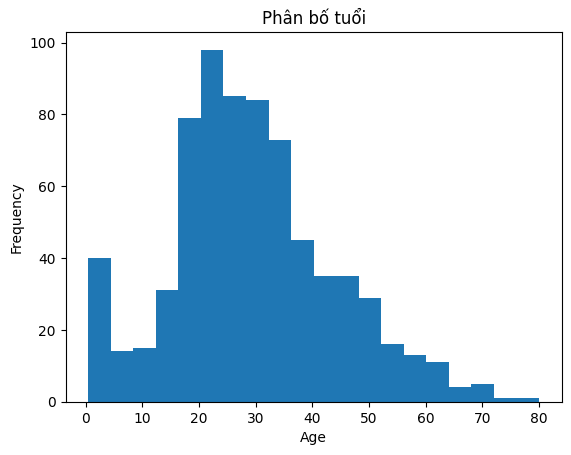

In [11]:
# Phân bố tuổi
train["Age"].plot(kind="hist", bins=20)
plt.title("Phân bố tuổi")
plt.xlabel("Age")
plt.show()

## 5. Data Preprocessing

Để giữ bài đơn giản giống tài liệu PDF, ta sử dụng các thuộc tính:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

Các bước:

- Điền tuổi thiếu bằng tuổi trung bình.
- Điền Fare thiếu bằng giá vé trung bình.
- One-hot encoding cho `Sex`, `Embarked`, `Pclass`.
- Chuẩn hóa các biến số.

In [12]:
def preprocess_titanic(df):
    data = df.copy()

    # Điền dữ liệu thiếu
    data["Age"] = data["Age"].fillna(data["Age"].mean())
    data["Fare"] = data["Fare"].fillna(data["Fare"].mean())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

    # One-hot encoding
    sex = pd.get_dummies(data["Sex"], prefix="Sex", drop_first=True)
    embark = pd.get_dummies(data["Embarked"], prefix="Embarked", drop_first=True)
    pclass = pd.get_dummies(data["Pclass"], prefix="Pclass", drop_first=True)

    data = pd.concat([data, sex, embark, pclass], axis=1)

    # Bỏ các cột không sử dụng
    data = data.drop(
        ["Pclass", "Sex", "Embarked", "Cabin", "PassengerId", "Name", "Ticket"],
        axis=1
    )

    return data


train_p = preprocess_titanic(train)
test_p = preprocess_titanic(test)

train_p.head()

,Survived,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,True,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,26.0,0,0,7.9250,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,True,False,True


### Đồng bộ cột giữa train và test

In [13]:
X = train_p.drop("Survived", axis=1)
y = train_p["Survived"]

# test không có cột Survived
X_test_kaggle = test_p.copy()

# Đảm bảo train và test có cùng cột
X, X_test_kaggle = X.align(
    X_test_kaggle,
    join="left",
    axis=1,
    fill_value=0
)

print("Các cột đầu vào:")
print(X.columns.tolist())

Các cột đầu vào:
['Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3']


### Xử lý dữ liệu

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=params["data"]["validation_size"],
    random_state=params["data"]["random_state"],
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_kaggle_scaled = scaler.transform(X_test_kaggle)

print(X_train.shape, X_val.shape)

(623, 9) (268, 9)


In [15]:
# Chuyển sang Tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_kaggle_t = torch.tensor(X_test_kaggle_scaled, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=params["train"]["batch_size"],
    shuffle=True
)

print(X_train_t.shape, y_train_t.shape)

torch.Size([623, 9]) torch.Size([623, 1])


## 6. Define Model

Mạng MLP đơn giản: Input → Linear → ReLU → Linear → ReLU → Output

In [16]:
class TitanicMLP(nn.Module):
    def __init__(self, input_size, hidden1=32, hidden2=16):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),

            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.net(x)


model = TitanicMLP(
    input_size=X_train.shape[1],
    hidden1=params["train"]["hidden1"],
    hidden2=params["train"]["hidden2"]
)

print(model)

TitanicMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 7. Fit Model

In [17]:
run = wandb.init(
    project=params["wandb"]["project"],
    name="baseline",
    config=params["train"],
    mode=params["wandb"]["mode"]
)

In [18]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=params["train"]["learning_rate"])

epochs = params["train"]["epochs"]

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation
    model.eval()

    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits)
        val_pred = (val_probs >= 0.5).int().numpy().ravel()

    val_acc = accuracy_score(y_val, val_pred)
    avg_loss = total_loss / len(train_loader)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "val_accuracy": val_acc
    })

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d}/{epochs} - "
            f"Loss: {avg_loss:.4f} - "
            f"Val Acc: {val_acc:.4f}"
        )

wandb.finish()

Epoch  10/100 - Loss: 0.3930 - Val Acc: 0.8172
Epoch  20/100 - Loss: 0.3809 - Val Acc: 0.8246
Epoch  30/100 - Loss: 0.3682 - Val Acc: 0.8134
Epoch  40/100 - Loss: 0.3558 - Val Acc: 0.8284
Epoch  50/100 - Loss: 0.3423 - Val Acc: 0.8284
Epoch  60/100 - Loss: 0.3441 - Val Acc: 0.8284
Epoch  70/100 - Loss: 0.3389 - Val Acc: 0.8209
Epoch  80/100 - Loss: 0.3332 - Val Acc: 0.8246
Epoch  90/100 - Loss: 0.3257 - Val Acc: 0.8246
Epoch 100/100 - Loss: 0.3215 - Val Acc: 0.8209


## 8. Model Evaluation

In [19]:
model.eval()

with torch.no_grad():
    logits = model(X_val_t)
    probs = torch.sigmoid(logits)
    predictions = (probs >= 0.5).int().numpy().ravel()

print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       165
           1       0.84      0.66      0.74       103

    accuracy                           0.82       268
   macro avg       0.83      0.79      0.80       268
weighted avg       0.82      0.82      0.82       268



In [20]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, predictions))

print("\nAccuracy:")
print(accuracy_score(y_val, predictions))

Confusion Matrix:
[[152  13]
 [ 35  68]]

Accuracy:
0.8208955223880597


## 9. Tinh chỉnh tham số mạng đơn giản

In [21]:
results = []

for cfg in params["tuning"]:

    print("\nĐang huấn luyện:", cfg["name"])

    # DataLoader riêng vì mỗi cấu hình có thể có batch_size khác nhau
    tuning_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=cfg["batch_size"],
        shuffle=True
    )

    m = TitanicMLP(
        input_size=X_train.shape[1],
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"]
    )

    optimizer = torch.optim.Adam(
        m.parameters(),
        lr=cfg["learning_rate"]
    )

    criterion = nn.BCEWithLogitsLoss()

    # Mỗi cấu hình tuning là một W&B run
    run = wandb.init(
        project=params["wandb"]["project"],
        name=f'tuning-{cfg["name"]}',
        config=cfg,
        mode=params["wandb"]["mode"],
        reinit=True
    )

    for epoch in range(cfg["epochs"]):
        m.train()
        total_loss = 0

        for xb, yb in tuning_loader:
            optimizer.zero_grad()

            logits = m(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Validation
        m.eval()

        with torch.no_grad():
            val_logits = m(X_val_t)
            val_pred = (
                torch.sigmoid(val_logits) >= 0.5
            ).int().numpy().ravel()

        acc = accuracy_score(y_val, val_pred)
        avg_loss = total_loss / len(tuning_loader)

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_loss,
            "val_accuracy": acc
        })

    wandb.finish()

    # Accuracy cuối cùng của cấu hình
    m.eval()

    with torch.no_grad():
        pred = (
            torch.sigmoid(m(X_val_t)) >= 0.5
        ).int().numpy().ravel()

    acc = accuracy_score(y_val, pred)

    results.append({
        "name": cfg["name"],
        "hidden1": cfg["hidden1"],
        "hidden2": cfg["hidden2"],
        "learning_rate": cfg["learning_rate"],
        "batch_size": cfg["batch_size"],
        "epochs": cfg["epochs"],
        "accuracy": acc,
        "model": m
    })


# Bảng so sánh các cấu hình
result_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "model"}
    for r in results
])

result_df


Đang huấn luyện: small

Đang huấn luyện: medium

Đang huấn luyện: large


,name,hidden1,hidden2,learning_rate,batch_size,epochs,accuracy
0,small,16,8,0.001,32,100,0.813433
1,medium,32,16,0.001,32,100,0.809701
2,large,64,32,0.001,32,100,0.802239


In [22]:
best_result = max(results, key=lambda x: x["accuracy"])

best_model = best_result["model"]

print("Cấu hình tốt nhất:")
print("name          =", best_result["name"])
print("hidden1       =", best_result["hidden1"])
print("hidden2       =", best_result["hidden2"])
print("learning_rate =", best_result["learning_rate"])
print("batch_size    =", best_result["batch_size"])
print("epochs        =", best_result["epochs"])
print("accuracy      =", best_result["accuracy"])

# ------------------------------------------------------------
# Lưu best_model vào thư mục gốc của thí nghiệm
# ------------------------------------------------------------
torch.save({
    "model_state_dict": best_model.state_dict(),
    "input_size": X_train.shape[1],
    "hidden1": best_result["hidden1"],
    "hidden2": best_result["hidden2"],
    "accuracy": best_result["accuracy"],
    "config": {
        "name": best_result["name"],
        "hidden1": best_result["hidden1"],
        "hidden2": best_result["hidden2"],
        "learning_rate": best_result["learning_rate"],
        "batch_size": best_result["batch_size"],
        "epochs": best_result["epochs"]
    }
}, best_model_path)

print("\nĐã lưu best model:")
print(best_model_path)

# Ghi thông tin cấu hình tốt nhất vào params và cập nhật params.json
params["best"] = {
    "name": best_result["name"],
    "hidden1": best_result["hidden1"],
    "hidden2": best_result["hidden2"],
    "learning_rate": best_result["learning_rate"],
    "batch_size": best_result["batch_size"],
    "epochs": best_result["epochs"],
    "validation_accuracy": float(best_result["accuracy"])
}

with open(params_path, "w", encoding="utf-8") as f:
    json.dump(params, f, ensure_ascii=False, indent=4)

print("Đã cập nhật params.json với cấu hình tốt nhất:")
print(params_path)

Cấu hình tốt nhất:
name          = small
hidden1       = 16
hidden2       = 8
learning_rate = 0.001
batch_size    = 32
epochs        = 100
accuracy      = 0.8134328358208955

Đã lưu best model:
experiments\titanic_mlp_v1\best_model.pt
Đã cập nhật params.json với cấu hình tốt nhất:
experiments\titanic_mlp_v1\params.json


## 10. Prediction cho tập test Kaggle

In [23]:
# Nạp lại `best_model` từ thư mục thí nghiệm
checkpoint = torch.load(
    best_model_path,
    map_location="cpu"
)

best_model = TitanicMLP(
    input_size=checkpoint["input_size"],
    hidden1=checkpoint["hidden1"],
    hidden2=checkpoint["hidden2"]
)

best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model.eval()

print("Đã nạp model từ:")
print(best_model_path)

print("Validation accuracy đã lưu:")
print(checkpoint["accuracy"])

Đã nạp model từ:
experiments\titanic_mlp_v1\best_model.pt
Validation accuracy đã lưu:
0.8134328358208955


In [24]:
best_model.eval()

with torch.no_grad():
    test_logits = best_model(X_kaggle_t)

    test_probabilities = torch.sigmoid(test_logits)

    test_predictions = (
        test_probabilities >= 0.5
    ).int().numpy().ravel()

print(test_predictions[:20])
print("Số dự đoán:", len(test_predictions))

[0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]
Số dự đoán: 418


## 11. Submission

In [25]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0


In [26]:
submission.to_csv(
    submission_path,
    index=False
)

print("=" * 70)
print("SUBMISSION")
print("Đã tạo file :", submission_path)
print("Kích thước  :", submission.shape)
print("=" * 70)

SUBMISSION
Đã tạo file : /kaggle/working\submission.csv
Kích thước  : (418, 2)


In [27]:
#  Kiểm tra file submission
check_submission = pd.read_csv(
    submission_path
)

print(check_submission.head())
print()
print(check_submission.info())

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None


## Kết luận

Quy trình huấn luyện: Load Data → Data Analysis → Data Preprocessing → Define Model → Fit Model → Model Evaluation → Tuning → Prediction → Submission

Mô hình huấn luyện MLP bằng PyTorch:

- Mô hình được xây dựng bằng `torch.nn.Module`.
- Huấn luyện bằng vòng lặp PyTorch.
- Dùng `BCEWithLogitsLoss`.
- Dùng `Adam`.
- Dự đoán xác suất bằng `torch.sigmoid`.
- Kết quả cuối cùng được lưu vào `submission.csv` để nộp Kaggle.

Quản lý kết quả thí nghiệm

Toàn bộ thông tin tái lập thí nghiệm được gom về:

```text
experiments/<expr_name>/
├── best_model.pt
├── params.json
├── tuning_results.csv
└── images/
```

## Kết thúc


In [28]:
print("=" * 70)
print("KẾT THÚC THÍ NGHIỆM")
print("Thời gian:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Artifacts:", expr_path)
print("=" * 70)

KẾT THÚC THÍ NGHIỆM
Thời gian: 2026-09-17 15:56:07
Artifacts: experiments\titanic_mlp_v1
